# Customer Churn Prediction Analysis

## Step 1: EDA — Data Understanding & Exploration


In [9]:
# 1.1 Basic checks
print("Dataset shape:", df.shape)
print("\nColumn data types:")
print(df.dtypes)
print("\nMissing value counts:")
print(df.isnull().sum())
print("\nNumber of duplicate rows:", df.duplicated().sum())


Dataset shape: (7043, 21)

Column data types:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

Missing value counts:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0

In [10]:
# 1.2 Fix known issues: TotalCharges is str type, convert to float; drop the meaningless customerID column
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.drop(columns=['customerID'], inplace=True)

print("TotalCharges dtype after conversion:", df['TotalCharges'].dtype)
print("TotalCharges NaN count:", df['TotalCharges'].isnull().sum())


TotalCharges dtype after conversion: float64
TotalCharges NaN count: 11


In [11]:
# 1.3 Target variable analysis —— check whether classes are balanced
print("Churn distribution (absolute):")
print(df['Churn'].value_counts())
print("\nChurn distribution (proportion):")
print(df['Churn'].value_counts(normalize=True).round(3))


Churn distribution (absolute):
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn distribution (proportion):
Churn
No     0.735
Yes    0.265
Name: proportion, dtype: float64


### 1.4 Visualization Analysis


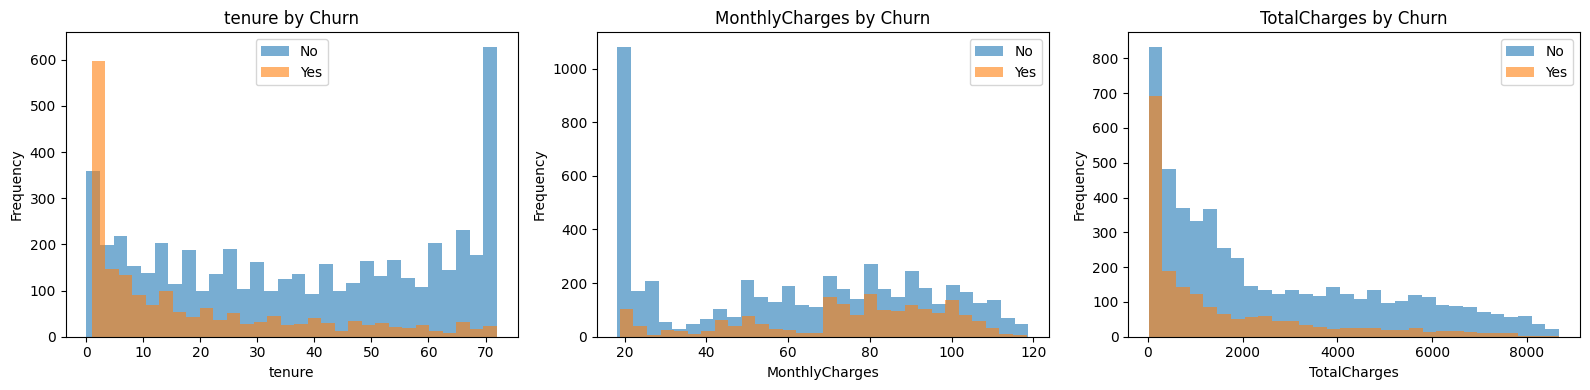

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Distribution of numeric features (grouped by Churn)
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, num_cols):
    df.groupby('Churn')[col].plot(kind='hist', alpha=0.6, ax=ax, legend=True, bins=30)
    ax.set_title(f'{col} by Churn')
    ax.set_xlabel(col)
plt.tight_layout()
plt.show()


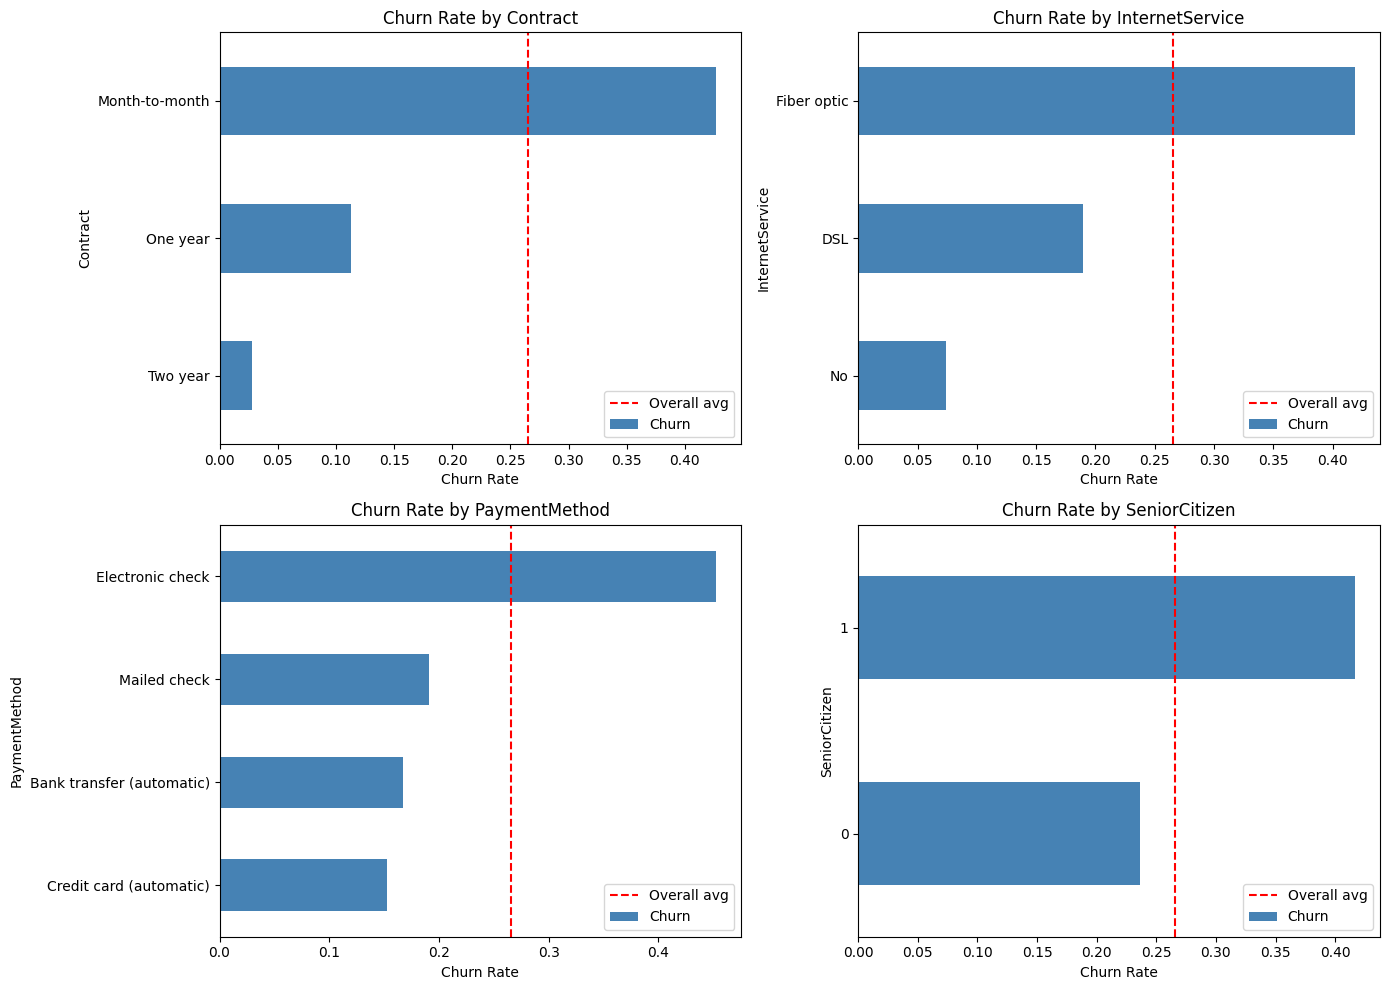

In [13]:
# Relationship between key categorical features and churn rate
cat_cols = ['Contract', 'InternetService', 'PaymentMethod', 'SeniorCitizen']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, col in zip(axes.flat, cat_cols):
    churn_rate = df.groupby(col)['Churn'].apply(lambda x: (x == 'Yes').mean())
    churn_rate.sort_values().plot(kind='barh', ax=ax, color='steelblue')
    ax.set_title(f'Churn Rate by {col}')
    ax.set_xlabel('Churn Rate')
    ax.axvline(df['Churn'].apply(lambda x: 1 if x == 'Yes' else 0).mean(),
               color='red', linestyle='--', label='Overall avg')
    ax.legend()
plt.tight_layout()
plt.show()


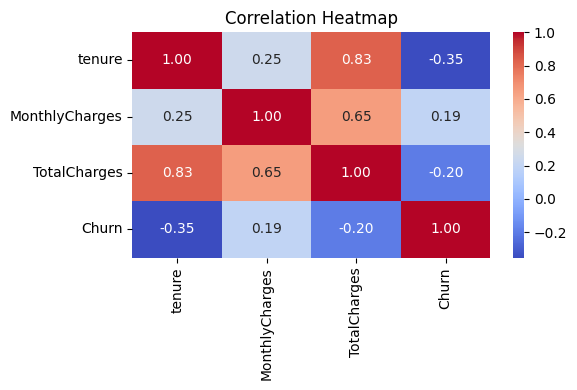

In [14]:
# Correlation heatmap of numeric features
plt.figure(figsize=(6, 4))
corr = df[num_cols + ['Churn']].copy()
corr['Churn'] = corr['Churn'].map({'Yes': 1, 'No': 0})
sns.heatmap(corr.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()


## Step 2: Data Preprocessing


In [15]:
# 2.1 Handle missing values (fill the small number of TotalCharges NaNs with the median)
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

# 2.2 Encode the target variable
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# 2.3 Encode binary categorical features
binary_map = {'Yes': 1, 'No': 0, 'Male': 1, 'Female': 0,
              'No phone service': 0, 'No internet service': 0}

binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService',
               'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
               'DeviceProtection', 'TechSupport', 'StreamingTV',
               'StreamingMovies', 'PaperlessBilling']

for col in binary_cols:
    df[col] = df[col].map(lambda x: binary_map.get(x, x))

# 2.4 One-Hot encode multi-valued categorical features
multi_cols = ['InternetService', 'Contract', 'PaymentMethod']
df = pd.get_dummies(df, columns=multi_cols, drop_first=True)

print("Preprocessing complete, data shape:", df.shape)
df.head(3)


Preprocessing complete, data shape: (7043, 24)


/tmp/ipykernel_3671/3423998896.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,MonthlyCharges,TotalCharges,Churn,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,0,0,1,0,...,29.85,29.85,0,False,False,False,False,False,True,False
1,1,0,0,0,34,1,0,1,0,1,...,56.95,1889.50,0,False,False,True,False,False,False,True
2,1,0,0,0,2,1,0,1,1,0,...,53.85,108.15,1,False,False,False,False,False,False,True


## Step 3: Feature Engineering


In [16]:
# tenure grouping: new customer (0-12 months) / mid-term (13-36 months) / long-term (>36 months)
df['tenure_group'] = pd.cut(df['tenure'],
                            bins=[0, 12, 36, df['tenure'].max()],
                            labels=[0, 1, 2],   # 0=new 1=mid 2=long-term
                            include_lowest=True).astype(int)

# Average monthly spend intensity (avoid division by zero)
df['charges_per_month'] = df.apply(
    lambda r: r['TotalCharges'] / r['tenure'] if r['tenure'] > 0 else r['MonthlyCharges'],
    axis=1
)

# Total number of subscribed services (7 value-added services)
service_cols = ['MultipleLines', 'OnlineSecurity', 'OnlineBackup',
                'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
df['num_services'] = df[service_cols].sum(axis=1)

print("Data shape after adding new features:", df.shape)
df[['tenure', 'tenure_group', 'TotalCharges', 'charges_per_month', 'num_services']].head()


Data shape after adding new features: (7043, 27)


,tenure,tenure_group,TotalCharges,charges_per_month,num_services
0,1,0,29.85,29.850000,1
1,34,1,1889.50,55.573529,2
2,2,0,108.15,54.075000,2
3,45,2,1840.75,40.905556,3
4,2,0,151.65,75.825000,0


## Step 4: Modeling


In [17]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

X = df.drop('Churn', axis=1)
y = df['Churn']

# 4.1 Split into train / test sets (stratify keeps the Churn ratio consistent)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 4.2 SMOTE oversampling to fix class imbalance (train set only)
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

print("Original train set Churn distribution:", y_train.value_counts().to_dict())
print("Train set Churn distribution after SMOTE:", y_train_res.value_counts().to_dict())

# 4.3 Standardization (helps LR; tree models can skip it, but applying it uniformly is harmless)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_res)
X_test_scaled  = scaler.transform(X_test)


Original train set Churn distribution: {0: 4139, 1: 1495}
Train set Churn distribution after SMOTE: {0: 4139, 1: 4139}


In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost':             XGBClassifier(n_estimators=100, use_label_encoder=False,
                                         eval_metric='logloss', random_state=42),
}

trained = {}
for name, model in models.items():
    # LR uses scaled data, tree models use the raw data
    Xtr = X_train_scaled if name == 'Logistic Regression' else X_train_res
    model.fit(Xtr, y_train_res)
    trained[name] = model
    print(f"{name} training complete")


Logistic Regression training complete
Random Forest training complete
XGBoost training complete


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [13:54:50] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


## Step 5: Model Evaluation

> In churn prediction, **Recall** and **F1** matter more than Accuracy — missing real churners costs far more than false alarms.


In [23]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

results = {}
for name, model in trained.items():
    Xte = X_test_scaled if name == 'Logistic Regression' else X_test
    y_pred      = model.predict(Xte)
    y_pred_prob = model.predict_proba(Xte)[:, 1]
    auc = roc_auc_score(y_test, y_pred_prob)
    results[name] = {'pred': y_pred, 'prob': y_pred_prob, 'auc': auc}

    print(f"\n{'='*50}")
    print(f"  {name}  |  AUC: {auc:.4f}")
    print('='*50)
    print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))


  Logistic Regression  |  AUC: 0.8281  |  Threshold: 0.3
              precision    recall  f1-score   support

    No Churn       0.92      0.67      0.77      1035
       Churn       0.47      0.83      0.60       374

    accuracy                           0.71      1409
   macro avg       0.70      0.75      0.69      1409
weighted avg       0.80      0.71      0.73      1409


  Random Forest  |  AUC: 0.8223  |  Threshold: 0.3
              precision    recall  f1-score   support

    No Churn       0.91      0.69      0.79      1035
       Churn       0.49      0.81      0.61       374

    accuracy                           0.72      1409
   macro avg       0.70      0.75      0.70      1409
weighted avg       0.80      0.72      0.74      1409


  XGBoost  |  AUC: 0.8114  |  Threshold: 0.3
              precision    recall  f1-score   support

    No Churn       0.89      0.75      0.82      1035
       Churn       0.52      0.74      0.61       374

    accuracy              

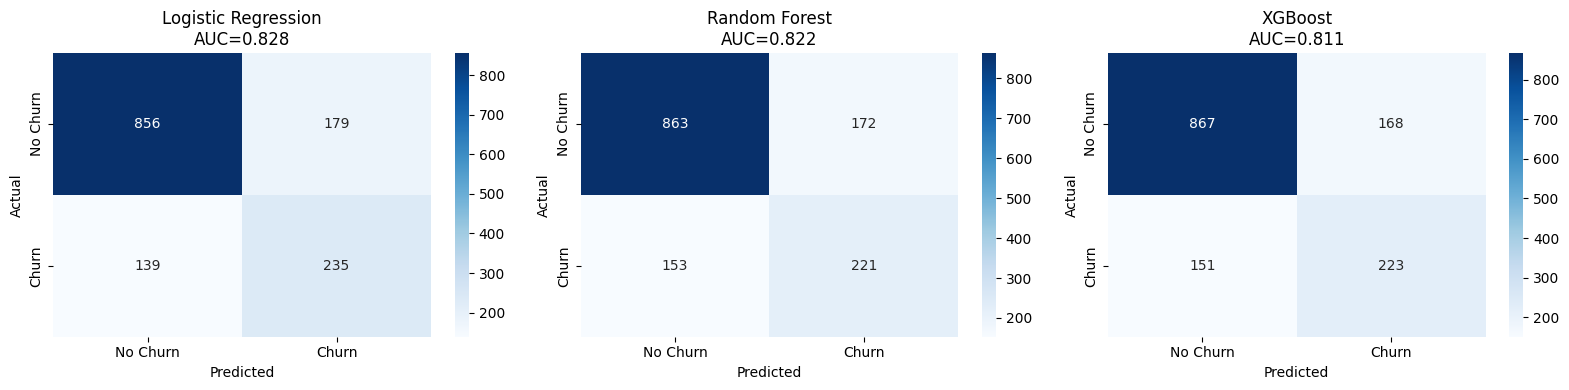

In [20]:
# Confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No Churn', 'Churn'],
                yticklabels=['No Churn', 'Churn'])
    ax.set_title(f'{name}\nAUC={res["auc"]:.3f}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()


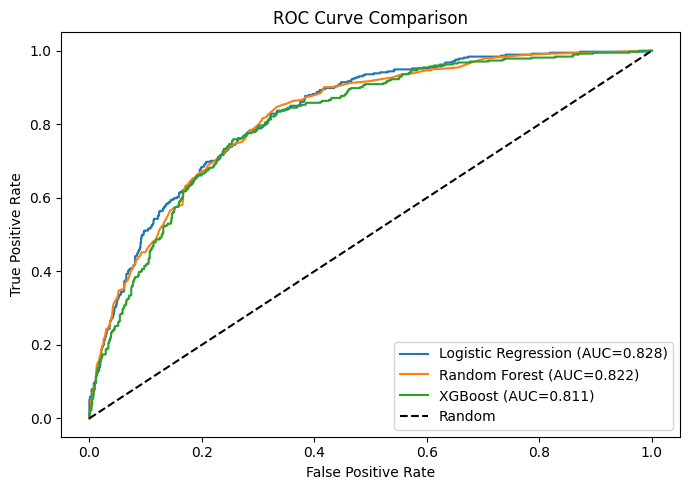

In [21]:
# ROC curve comparison
plt.figure(figsize=(7, 5))
for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res['prob'])
    plt.plot(fpr, tpr, label=f"{name} (AUC={res['auc']:.3f})")
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.tight_layout()
plt.show()


## Step 6: Feature Importance & Business Insights


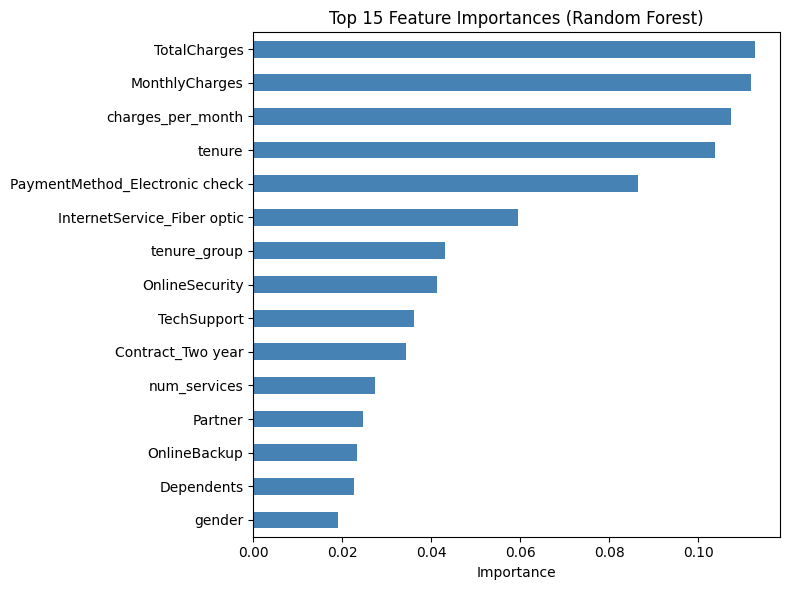


Top 10 most important features:
TotalCharges                      0.112773
MonthlyCharges                    0.111849
charges_per_month                 0.107470
tenure                            0.103820
PaymentMethod_Electronic check    0.086528
InternetService_Fiber optic       0.059600
tenure_group                      0.043166
OnlineSecurity                    0.041237
TechSupport                       0.036160
Contract_Two year                 0.034344
dtype: float64


In [22]:
# Random Forest feature importance (Top 15)
rf_model = trained['Random Forest']
feat_imp = pd.Series(rf_model.feature_importances_, index=X.columns)
top15 = feat_imp.sort_values(ascending=False).head(15)

plt.figure(figsize=(8, 6))
top15.sort_values().plot(kind='barh', color='steelblue')
plt.title('Top 15 Feature Importances (Random Forest)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

print("\nTop 10 most important features:")
print(feat_imp.sort_values(ascending=False).head(10))


## Business Conclusions & Recommendations

Based on the model analysis, the following factors have the greatest impact on customer churn:

| Key Factor | Churn Risk Description | Recommended Action |
|---|---|---|
| **Contract type** | Month-to-month contracts have the highest churn rate (~42%) | Encourage customers to upgrade to one- or two-year contracts, with discount incentives |
| **tenure** | New customers (<12 months) churn significantly more than long-tenured ones | Strengthen customer care and onboarding in the first 3 months to improve stickiness |
| **MonthlyCharges** | Higher monthly charges correlate with higher churn | Proactively recommend plan-optimization options to high-bill customers |
| **InternetService** | Fiber optic users churn more than DSL users | Improve fiber service quality or offer exclusive discounts |
| **Tech support / security services** | Customers without these services churn more | Recommend value-added services to customers to increase perceived plan value |

**Model selection recommendation**: XGBoost typically achieves the highest AUC; if interpretability is needed, Logistic Regression is also a good choice.
